# AirShift — Feature Engineering

This notebook transforms the cleaned air quality data into meaningful features for the AirShift early-warning machine learning task.

The feature engineering process focuses on:

* Creating useful time-based features
* Capturing previous air quality conditions using lag features
* Measuring recent pollution patterns using rolling statistics
* Capturing changes and trends in air quality
* Preparing the data for defining future deterioration events

All features are created using information available at or before each observation to avoid future data leakage.


In [24]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

In [25]:
DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/processed")

print("Processed data directory:")
print(DATA_DIR.resolve())

Processed data directory:
C:\Users\HP\Desktop\Projects\airshift\data\processed


In [26]:
cleaned_file = DATA_DIR / "airshift_cleaned.csv"

df = pd.read_csv(
    cleaned_file,
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)
print("\nFirst rows:")
df.head()

Dataset shape: (420768, 19)

First rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


## 1. Inspect Current Dataset

Before creating new features, we review the cleaned dataset to confirm its structure and the variables available for feature engineering.

This provides a baseline for deciding which temporal, historical, and trend-based features should be created.


In [27]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (420768, 19)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime']

Data types:
No                   int64
year                 int64
month                int64
day                  int64
hour                 int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                     str
WSPM               float64
station                str
datetime    datetime64[us]
dtype: object


In [28]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


### Inspection Findings

The cleaned dataset contains 420,768 observations and 19 columns representing hourly air quality measurements from 12 monitoring stations.

The dataset includes pollutant, meteorological, temporal, station, and datetime variables. The data types and overall structure are appropriate for the feature engineering stage.

The dataset is ready for temporal ordering and the creation of new time-based and historical features.


## 2. Prepare Data for Feature Engineering

Before creating temporal features, the dataset is sorted by monitoring station and datetime.

This ensures that the observations are in the correct chronological order within each station. Proper ordering is essential for creating lag and rolling features based on previous observations.

All subsequent temporal features will be calculated separately within each monitoring station.


In [29]:
df = df.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

print("Data sorted by station and datetime.")

print("\nFirst rows after sorting:")
print(
    df[
        ["station", "datetime"]
    ].head()
)

Data sorted by station and datetime.

First rows after sorting:
        station            datetime
0  Aotizhongxin 2013-03-01 00:00:00
1  Aotizhongxin 2013-03-01 01:00:00
2  Aotizhongxin 2013-03-01 02:00:00
3  Aotizhongxin 2013-03-01 03:00:00
4  Aotizhongxin 2013-03-01 04:00:00


## 3. Time-Based Features

Air quality can vary depending on the time of day, day of the week, and season.

To capture these temporal patterns, new features are created from the existing `datetime` column. These features provide the model with additional information about when each observation occurred.

The time-based features include:

* `hour`: hour of the day.
* `day_of_week`: day of the week.
* `month`: month of the year.
* `is_weekend`: whether the observation occurred on a weekend.

These features are derived only from the observation timestamp and do not use any future information.


In [30]:
df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = df["datetime"].dt.dayofweek

df["month"] = df["datetime"].dt.month

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

print("Time-based features created successfully.")

df[
    [
        "datetime",
        "hour",
        "day_of_week",
        "month",
        "is_weekend"
    ]
].head(10)

Time-based features created successfully.


,datetime,hour,day_of_week,month,is_weekend
0,2013-03-01 00:00:00,0,4,3,0
1,2013-03-01 01:00:00,1,4,3,0
2,2013-03-01 02:00:00,2,4,3,0
3,2013-03-01 03:00:00,3,4,3,0
4,2013-03-01 04:00:00,4,4,3,0
5,2013-03-01 05:00:00,5,4,3,0
6,2013-03-01 06:00:00,6,4,3,0
7,2013-03-01 07:00:00,7,4,3,0
8,2013-03-01 08:00:00,8,4,3,0
9,2013-03-01 09:00:00,9,4,3,0


### Time-Based Features Findings

The time-based features were created successfully from the `datetime` column.

The new features capture the hour of the day, day of the week, month, and whether an observation occurred on a weekend. These features provide the model with additional temporal context that may help capture recurring patterns in air quality.

All features are derived from the observation timestamp and do not use future information.


## 4. Lag Features

Air quality conditions are influenced by previous conditions, and changes in pollutant levels over time can provide important early warning signals.

Lag features capture the value of a variable from previous time points. For example, a one-hour lag of `PM2.5` represents the PM2.5 concentration measured one hour earlier.

For AirShift, lag features are created for the main pollutant variables using selected previous time intervals.

The lag intervals include:

* 1 hour
* 3 hours
* 6 hours

These features allow the model to compare the current air quality conditions with recent historical conditions while using only information available at or before the prediction time.


In [31]:
pollutant_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

lag_hours = [1, 3, 6]

for column in pollutant_columns:
    for lag in lag_hours:
        df[f"{column}_lag_{lag}h"] = (
            df.groupby("station")[column]
              .shift(lag)
        )

print("Lag features created successfully.")

lag_columns = [
    column
    for column in df.columns
    if "_lag_" in column
]

print("\nLag features:")
print(lag_columns)

print("\nNumber of lag features:", len(lag_columns))

Lag features created successfully.

Lag features:
['PM2.5_lag_1h', 'PM2.5_lag_3h', 'PM2.5_lag_6h', 'PM10_lag_1h', 'PM10_lag_3h', 'PM10_lag_6h', 'SO2_lag_1h', 'SO2_lag_3h', 'SO2_lag_6h', 'NO2_lag_1h', 'NO2_lag_3h', 'NO2_lag_6h', 'CO_lag_1h', 'CO_lag_3h', 'CO_lag_6h', 'O3_lag_1h', 'O3_lag_3h', 'O3_lag_6h']

Number of lag features: 18


### Validate Lag Features

After creating the lag features, their values are inspected to verify that they correctly represent previous observations within each monitoring station.

The first observations of each station are expected to contain missing values because previous measurements are not available for those timestamps.

This validation ensures that lag features are calculated in chronological order and do not use information from other stations or future observations.


In [32]:
df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_lag_1h",
        "PM2.5_lag_3h",
        "PM2.5_lag_6h"
    ]
].head(10)

,station,datetime,PM2.5,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,4.0,NaN,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,8.0,NaN,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,7.0,4.0,NaN
4,Aotizhongxin,2013-03-01 04:00:00,3.0,6.0,8.0,NaN
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0,7.0,NaN
6,Aotizhongxin,2013-03-01 06:00:00,3.0,5.0,6.0,4.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0,3.0,8.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,3.0,5.0,7.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,3.0,3.0,6.0


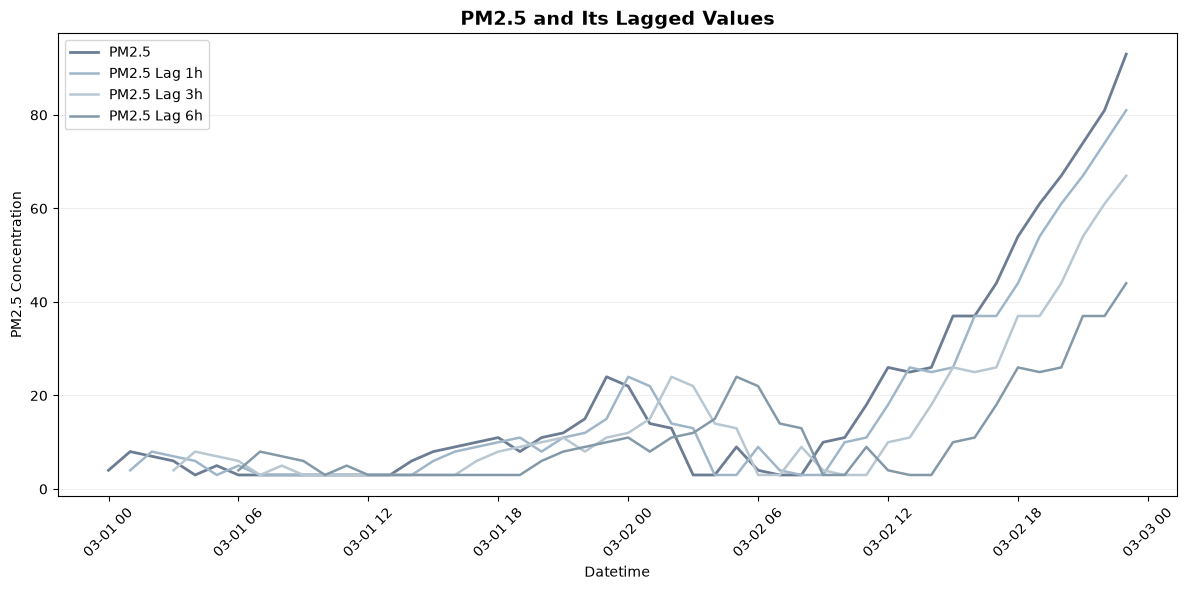

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\03_feature_engineering\figure_04_pm25_and_lagged_values.png


In [33]:
# Create the Feature Engineering figures directory
FIGURES_DIR = Path("../reports/figures/03_feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Select one station and a short time period for visualization
plot_data = df[
    df["station"] == "Aotizhongxin"
].iloc[:48].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5"],
    label="PM2.5",
    color="#6B7C93",
    linewidth=2
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_1h"],
    label="PM2.5 Lag 1h",
    color="#9FB6C9",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_3h"],
    label="PM2.5 Lag 3h",
    color="#B8C7D1",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_lag_6h"],
    label="PM2.5 Lag 6h",
    color="#8499A8",
    linewidth=1.8
)

plt.title(
    "PM2.5 and Its Lagged Values",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Datetime")
plt.ylabel("PM2.5 Concentration")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=45)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_04_pm25_and_lagged_values.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

## 5. Rolling Features

Lag features capture pollutant values at specific previous time points, while rolling features summarize recent air quality conditions over a continuous time window.

Rolling statistics can help the model capture recent pollution levels, peaks, and variability that may provide early warning signals of future deterioration.

For AirShift, rolling features are created using the previous observations within each monitoring station.

The following rolling statistics are calculated:

* Rolling mean to represent the recent average pollutant level.
* Rolling maximum to capture recent pollution peaks.
* Rolling standard deviation to measure recent variability.

The rolling windows include:

* 3 hours
* 6 hours

Only previous observations are used to calculate these features. The current observation is excluded to ensure that the features do not use information from the prediction time itself.


In [34]:
rolling_windows = [3, 6]

for column in pollutant_columns:
    for window in rolling_windows:
        
        df[f"{column}_rolling_mean_{window}h"] = (
            df.groupby("station")[column]
              .transform(
                  lambda x: x.shift(1).rolling(window=window).mean()
              )
        )
        
        df[f"{column}_rolling_max_{window}h"] = (
            df.groupby("station")[column]
              .transform(
                  lambda x: x.shift(1).rolling(window=window).max()
              )
        )
        
        df[f"{column}_rolling_std_{window}h"] = (
            df.groupby("station")[column]
              .transform(
                  lambda x: x.shift(1).rolling(window=window).std()
              )
        )

print("Rolling features created successfully.")

rolling_columns = [
    column
    for column in df.columns
    if "_rolling_" in column
]

print("\nNumber of rolling features:", len(rolling_columns))

print("\nRolling features:")
print(rolling_columns)

Rolling features created successfully.

Number of rolling features: 36

Rolling features:
['PM2.5_rolling_mean_3h', 'PM2.5_rolling_max_3h', 'PM2.5_rolling_std_3h', 'PM2.5_rolling_mean_6h', 'PM2.5_rolling_max_6h', 'PM2.5_rolling_std_6h', 'PM10_rolling_mean_3h', 'PM10_rolling_max_3h', 'PM10_rolling_std_3h', 'PM10_rolling_mean_6h', 'PM10_rolling_max_6h', 'PM10_rolling_std_6h', 'SO2_rolling_mean_3h', 'SO2_rolling_max_3h', 'SO2_rolling_std_3h', 'SO2_rolling_mean_6h', 'SO2_rolling_max_6h', 'SO2_rolling_std_6h', 'NO2_rolling_mean_3h', 'NO2_rolling_max_3h', 'NO2_rolling_std_3h', 'NO2_rolling_mean_6h', 'NO2_rolling_max_6h', 'NO2_rolling_std_6h', 'CO_rolling_mean_3h', 'CO_rolling_max_3h', 'CO_rolling_std_3h', 'CO_rolling_mean_6h', 'CO_rolling_max_6h', 'CO_rolling_std_6h', 'O3_rolling_mean_3h', 'O3_rolling_max_3h', 'O3_rolling_std_3h', 'O3_rolling_mean_6h', 'O3_rolling_max_6h', 'O3_rolling_std_6h']


### Rolling Features Validation

The rolling features were created successfully for all six pollutant variables using 3-hour and 6-hour windows.

The resulting features capture recent average levels, pollution peaks, and variability while using only previous observations.

These features provide the model with additional information about recent air quality conditions and short-term pollution patterns.


In [35]:
df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_rolling_mean_3h",
        "PM2.5_rolling_mean_6h",
        "PM2.5_rolling_max_3h",
        "PM2.5_rolling_std_3h"
    ]
].head(10)

,station,datetime,PM2.5,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_max_3h,PM2.5_rolling_std_3h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,NaN,NaN,NaN,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,NaN,NaN,NaN,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,6.333333,NaN,8.0,2.081666
4,Aotizhongxin,2013-03-01 04:00:00,3.0,7.000000,NaN,8.0,1.000000
5,Aotizhongxin,2013-03-01 05:00:00,5.0,5.333333,NaN,7.0,2.081666
6,Aotizhongxin,2013-03-01 06:00:00,3.0,4.666667,5.500000,6.0,1.527525
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.666667,5.333333,5.0,1.154701
8,Aotizhongxin,2013-03-01 08:00:00,3.0,3.666667,4.500000,5.0,1.154701
9,Aotizhongxin,2013-03-01 09:00:00,3.0,3.000000,3.833333,3.0,0.000000


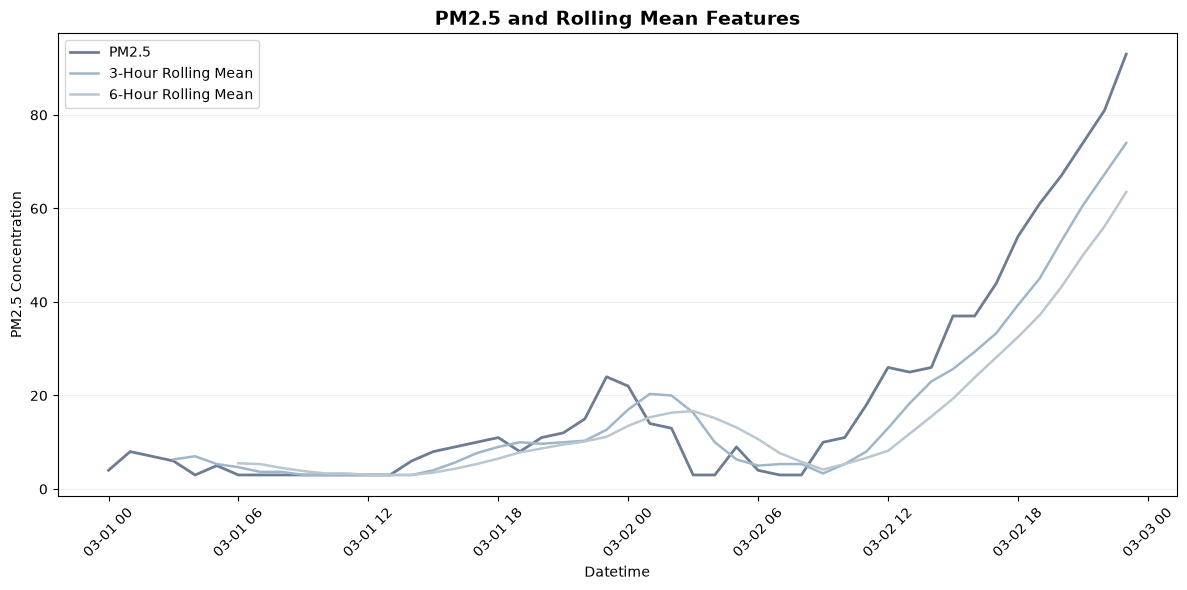

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\03_feature_engineering\figure_05_pm25_and_rolling_means.png


In [36]:
FIGURES_DIR = Path("../reports/figures/03_feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_data = df[
    df["station"] == "Aotizhongxin"
].iloc[:48].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5"],
    label="PM2.5",
    color="#6B7C93",
    linewidth=2
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_rolling_mean_3h"],
    label="3-Hour Rolling Mean",
    color="#9FB6C9",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_rolling_mean_6h"],
    label="6-Hour Rolling Mean",
    color="#B8C7D1",
    linewidth=1.8
)

plt.title(
    "PM2.5 and Rolling Mean Features",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Datetime")
plt.ylabel("PM2.5 Concentration")

plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.xticks(rotation=45)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_05_pm25_and_rolling_means.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

### Figure 5 — Rolling Features Findings

The figure shows how the 3-hour and 6-hour rolling means summarize recent PM2.5 conditions.

The shorter 3-hour window responds more quickly to recent changes, while the 6-hour window provides a smoother representation of recent pollution levels.

These features help capture short-term pollution patterns that may provide useful signals for early warning prediction.


## 6. Change and Trend Features

Changes in pollutant levels over time can provide important signals of air quality deterioration.

For AirShift, change and trend features are created to capture recent increases or decreases in pollutant concentrations.

The features compare current pollutant levels with previous observations while using only information available at the prediction time.


### 6.1 Change Features

Change features measure the difference between the current pollutant level and its previous value.

For each pollutant, the change from the previous hour and the previous 3 hours is calculated.


In [37]:
change_hours = [1, 3]

for column in pollutant_columns:
    for lag in change_hours:
        df[f"{column}_change_{lag}h"] = (
            df.groupby("station")[column]
              .diff(lag)
        )

print("Change features created successfully.")

change_columns = [
    column
    for column in df.columns
    if "_change_" in column
]

print("\nNumber of change features:", len(change_columns))

print("\nChange features:")
print(change_columns)

Change features created successfully.

Number of change features: 12

Change features:
['PM2.5_change_1h', 'PM2.5_change_3h', 'PM10_change_1h', 'PM10_change_3h', 'SO2_change_1h', 'SO2_change_3h', 'NO2_change_1h', 'NO2_change_3h', 'CO_change_1h', 'CO_change_3h', 'O3_change_1h', 'O3_change_3h']


### Change Features Validation

The change features were created successfully for all six pollutant variables using 1-hour and 3-hour intervals.

Positive values indicate an increase in pollutant concentration, while negative values indicate a decrease. These features capture recent changes in pollution levels that may provide early warning signals of deterioration.


In [38]:
df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_change_1h",
        "PM2.5_change_3h",
        "PM10",
        "PM10_change_1h",
        "PM10_change_3h"
    ]
].head(10)

,station,datetime,PM2.5,PM2.5_change_1h,PM2.5_change_3h,PM10,PM10_change_1h,PM10_change_3h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN,4.0,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,4.0,NaN,8.0,4.0,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,-1.0,NaN,7.0,-1.0,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,-1.0,2.0,6.0,-1.0,2.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,-3.0,-5.0,3.0,-3.0,-5.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,2.0,-2.0,5.0,2.0,-2.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,-2.0,-3.0,3.0,-2.0,-3.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,0.0,0.0,6.0,3.0,3.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,0.0,-2.0,6.0,0.0,1.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,0.0,0.0,8.0,2.0,5.0


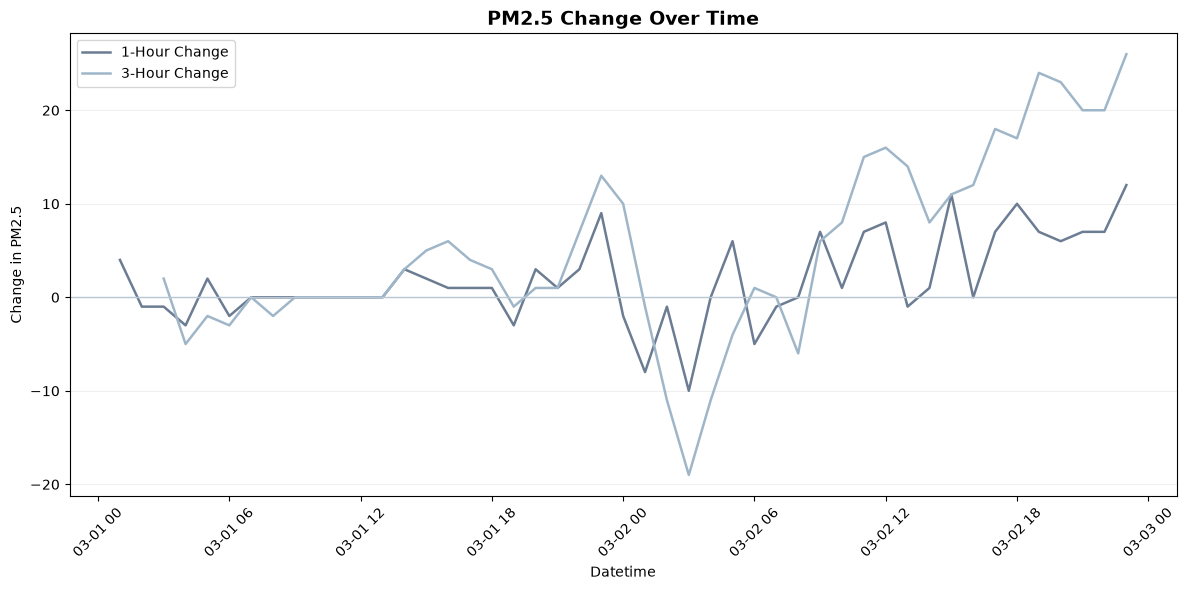

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\03_feature_engineering\figure_06_1_pm25_change_over_time.png


In [39]:
FIGURES_DIR = Path("../reports/figures/03_feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_data = df[
    df["station"] == "Aotizhongxin"
].iloc[:48].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_change_1h"],
    label="1-Hour Change",
    color="#6B7C93",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_change_3h"],
    label="3-Hour Change",
    color="#9FB6C9",
    linewidth=1.8
)

plt.axhline(
    0,
    color="#B8C7D1",
    linewidth=1
)

plt.title(
    "PM2.5 Change Over Time",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Datetime")
plt.ylabel("Change in PM2.5")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=45)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_06_1_pm25_change_over_time.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

### Figure 6.1 — Change Features Findings

The figure shows the changes in PM2.5 concentration over 1-hour and 3-hour intervals.

Positive values indicate increasing pollution levels, while negative values indicate decreasing levels. The shorter interval captures more immediate changes, whereas the 3-hour interval reflects broader short-term changes.

These features provide information about the direction and magnitude of recent pollution changes, which may help identify early deterioration patterns.


### 6.2 Trend Features

Trend features capture the direction of recent pollutant changes over time.

For each pollutant, a short-term trend is calculated over the previous 3 and 6 hours. Positive trends indicate increasing pollutant levels, while negative trends indicate decreasing levels.

Only previous observations are used to calculate the trends.


In [40]:
trend_windows = [3, 6]

for column in pollutant_columns:
    
    # 3-hour trend
    previous_3 = (
        df.groupby("station")[column]
          .shift(1)
    )

    previous_3h = (
        df.groupby("station")[column]
          .shift(3)
    )

    df[f"{column}_trend_3h"] = (
        previous_3 - previous_3h
    ) / 2

    # 6-hour trend
    x1 = df.groupby("station")[column].shift(1)
    x2 = df.groupby("station")[column].shift(2)
    x3 = df.groupby("station")[column].shift(3)
    x4 = df.groupby("station")[column].shift(4)
    x5 = df.groupby("station")[column].shift(5)
    x6 = df.groupby("station")[column].shift(6)

    df[f"{column}_trend_6h"] = (
        -5 * x6
        -3 * x5
        -1 * x4
        +1 * x3
        +3 * x2
        +5 * x1
    ) / 35

print("Trend features created successfully.")

trend_columns = [
    column
    for column in df.columns
    if "_trend_" in column
]

print("\nNumber of trend features:", len(trend_columns))

print("\nTrend features:")
print(trend_columns)

Trend features created successfully.

Number of trend features: 12

Trend features:
['PM2.5_trend_3h', 'PM2.5_trend_6h', 'PM10_trend_3h', 'PM10_trend_6h', 'SO2_trend_3h', 'SO2_trend_6h', 'NO2_trend_3h', 'NO2_trend_6h', 'CO_trend_3h', 'CO_trend_6h', 'O3_trend_3h', 'O3_trend_6h']


### Trend Features Validation

The trend features were created successfully for all six pollutant variables using 3-hour and 6-hour windows.

Positive values indicate an increasing trend, while negative values indicate a decreasing trend. These features provide information about the direction of recent pollution changes.


In [41]:
df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_trend_3h",
        "PM2.5_trend_6h",
        "PM10",
        "PM10_trend_3h",
        "PM10_trend_6h"
    ]
].head(10)

,station,datetime,PM2.5,PM2.5_trend_3h,PM2.5_trend_6h,PM10,PM10_trend_3h,PM10_trend_6h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,NaN,NaN,4.0,NaN,NaN
1,Aotizhongxin,2013-03-01 01:00:00,8.0,NaN,NaN,8.0,NaN,NaN
2,Aotizhongxin,2013-03-01 02:00:00,7.0,NaN,NaN,7.0,NaN,NaN
3,Aotizhongxin,2013-03-01 03:00:00,6.0,1.5,NaN,6.0,1.5,NaN
4,Aotizhongxin,2013-03-01 04:00:00,3.0,-1.0,NaN,3.0,-1.0,NaN
5,Aotizhongxin,2013-03-01 05:00:00,5.0,-2.0,NaN,5.0,-2.0,NaN
6,Aotizhongxin,2013-03-01 06:00:00,3.0,-0.5,-0.314286,3.0,-0.5,-0.314286
7,Aotizhongxin,2013-03-01 07:00:00,3.0,0.0,-0.971429,6.0,0.0,-0.971429
8,Aotizhongxin,2013-03-01 08:00:00,3.0,-1.0,-0.771429,6.0,0.5,-0.342857
9,Aotizhongxin,2013-03-01 09:00:00,3.0,0.0,-0.485714,8.0,1.5,0.200000


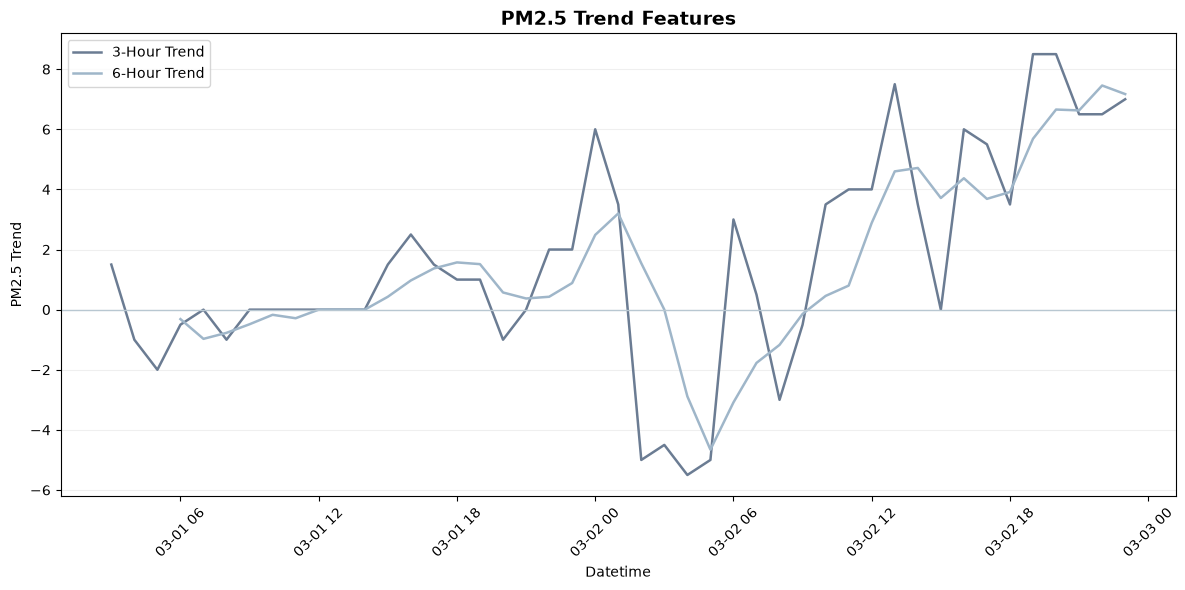

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\03_feature_engineering\figure_06_2_pm25_trend_features.png


In [42]:
FIGURES_DIR = Path("../reports/figures/03_feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_data = df[
    df["station"] == "Aotizhongxin"
].iloc[:48].copy()

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_trend_3h"],
    label="3-Hour Trend",
    color="#6B7C93",
    linewidth=1.8
)

plt.plot(
    plot_data["datetime"],
    plot_data["PM2.5_trend_6h"],
    label="6-Hour Trend",
    color="#9FB6C9",
    linewidth=1.8
)

plt.axhline(
    0,
    color="#B8C7D1",
    linewidth=1
)

plt.title(
    "PM2.5 Trend Features",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Datetime")
plt.ylabel("PM2.5 Trend")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.xticks(rotation=45)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_06_2_pm25_trend_features.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

### Figure 6.2 — Trend Features Findings

The figure shows the short-term trend of PM2.5 over 3-hour and 6-hour windows.

Positive values indicate an increasing trend, while negative values indicate a decreasing trend. The 3-hour trend responds more quickly to recent changes, whereas the 6-hour trend provides a more stable view of the overall direction.

These features help AirShift capture the direction of recent pollution changes, which may provide useful early warning signals.


## 7. Feature Engineering Summary

The feature engineering process created temporal, historical, rolling, change, and trend features from the cleaned air quality data.

These features are designed to capture recent air quality conditions and short-term changes while using only information available at or before each observation.

Before proceeding to deterioration event definition, the final feature set is validated to confirm the number of observations, columns, and newly created features.


In [43]:
print("Final dataset shape:", df.shape)

print("\nOriginal columns:", 19)

print("New time-based features:", 2)
print("New lag features:", len(lag_columns))
print("New rolling features:", len(rolling_columns))
print("New change features:", len(change_columns))
print("New trend features:", len(trend_columns))

total_new_features = (
    2
    + len(lag_columns)
    + len(rolling_columns)
    + len(change_columns)
    + len(trend_columns)
)

print("\nTotal new features:", total_new_features)
print("Expected total columns:", 19 + total_new_features)

Final dataset shape: (420768, 99)

Original columns: 19
New time-based features: 2
New lag features: 18
New rolling features: 36
New change features: 12
New trend features: 12

Total new features: 80
Expected total columns: 99


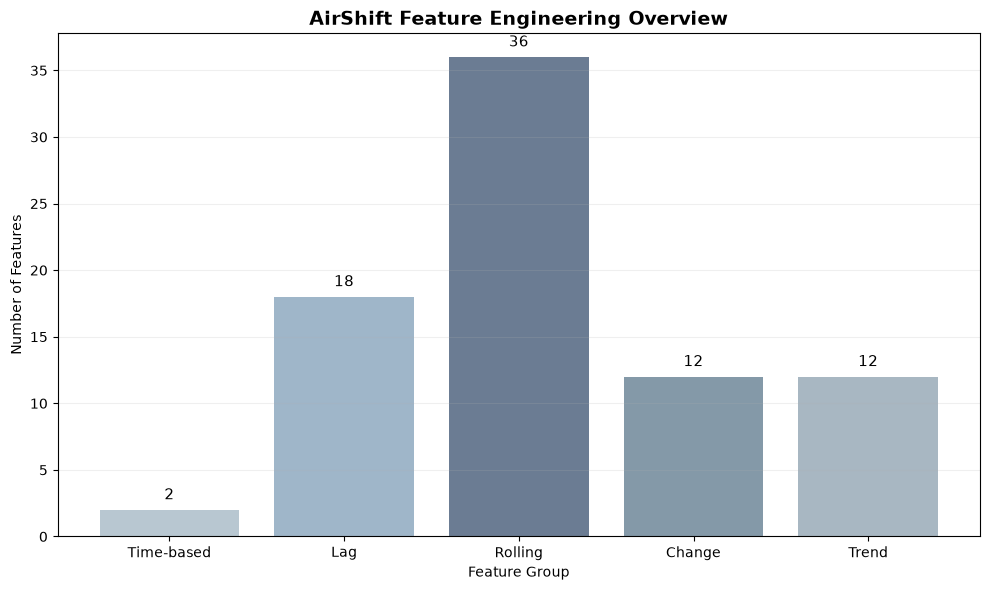

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\03_feature_engineering\figure_07_feature_engineering_overview.png


In [44]:
FIGURES_DIR = Path("../reports/figures/03_feature_engineering")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

feature_groups = [
    "Time-based",
    "Lag",
    "Rolling",
    "Change",
    "Trend"
]

feature_counts = [
    2,
    18,
    36,
    12,
    12
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    feature_groups,
    feature_counts,
    color=[
        "#B8C7D1",
        "#9FB6C9",
        "#6B7C93",
        "#8499A8",
        "#A8B7C2"
    ]
)

plt.title(
    "AirShift Feature Engineering Overview",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Group")
plt.ylabel("Number of Features")

plt.grid(
    axis="y",
    alpha=0.2
)

for bar, count in zip(bars, feature_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.8,
        str(count),
        ha="center",
        fontsize=11
    )

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "figure_07_feature_engineering_overview.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

### Figure 7 — Feature Engineering Overview Findings

The figure summarizes the 80 new features created during the feature engineering process.

Rolling features form the largest group, followed by lag, change, and trend features. The time-based features add information about the day of the week and weekend patterns, while the existing hour and month variables were retained.

The resulting dataset contains 99 columns and is ready for the next stage: defining future air quality deterioration events.


## 8. Save Feature-Engineered Dataset

The final feature-engineered dataset is saved separately from the raw and cleaned datasets.

This file contains the newly created temporal, lag, rolling, change, and trend features and will be used as the input dataset for the deterioration event definition stage.


In [45]:
feature_file = OUTPUT_DIR / "airshift_feature_engineered.csv"

df.to_csv(feature_file, index=False)

print("Feature-engineered dataset saved successfully:")
print(feature_file.resolve())

Feature-engineered dataset saved successfully:
C:\Users\HP\Desktop\Projects\airshift\data\processed\airshift_feature_engineered.csv
